In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
targets = ['r1','r2','r3','D1','D2','D3']

# Load all saved results
results = {
    'FFNN_A':    (np.load("true_inverse_A_FFNN.npy"), np.load("pred_inverse_A_FFNN.npy")),
    'FFNN_B':    (np.load("true_inverse_B_FFNN.npy"), np.load("pred_inverse_B_FFNN.npy")),
    'XGB_A':     (np.load("true_inverse_A_xgb.npy"),  np.load("pred_inverse_A_xgb.npy")),
    'XGB_B':     (np.load("true_inverse_B_xgb.npy"),  np.load("pred_inverse_B_xgb.npy")),
    'RF_A':      (np.load("true_inverse_A_RF.npy"),   np.load("pred_inverse_A_RF.npy")),
    'RF_B':      (np.load("true_inverse_B_RF.npy"),   np.load("pred_inverse_B_RF.npy")),
}
print("All files loaded successfully!")

All files loaded successfully!


In [3]:
rows = []
for model_name, (y_true, y_pred) in results.items():
    for i, t in enumerate(targets):
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        mae  = mean_absolute_error(y_true[:, i], y_pred[:, i])
        r2   = r2_score(y_true[:, i], y_pred[:, i])
        rows.append([model_name, t, round(rmse,4), round(mae,4), round(r2,4)])

df_results = pd.DataFrame(rows, columns=['Model', 'Parameter', 'RMSE', 'MAE', 'R2'])
print(df_results.to_string())
df_results.to_csv("all_results.csv", index=False)
print("\nSaved to all_results.csv!")

     Model Parameter    RMSE     MAE      R2
0   FFNN_A        r1  0.8314  0.6252  0.4695
1   FFNN_A        r2  1.1345  0.8915  0.3738
2   FFNN_A        r3  1.3852  1.1773  0.0491
3   FFNN_A        D1  0.0028  0.0017  0.8488
4   FFNN_A        D2  0.0016  0.0011  0.9488
5   FFNN_A        D3  0.0040  0.0032  0.3509
6   FFNN_B        r1  0.6213  0.4004  0.7038
7   FFNN_B        r2  0.9657  0.6808  0.5463
8   FFNN_B        r3  1.2895  1.0129  0.1759
9   FFNN_B        D1  0.0020  0.0014  0.9197
10  FFNN_B        D2  0.0010  0.0006  0.9798
11  FFNN_B        D3  0.0033  0.0024  0.5555
12   XGB_A        r1  0.9755  0.7648  0.2698
13   XGB_A        r2  1.2793  1.0200  0.2037
14   XGB_A        r3  1.4790  1.2375 -0.0840
15   XGB_A        D1  0.0033  0.0021  0.7825
16   XGB_A        D2  0.0020  0.0014  0.9217
17   XGB_A        D3  0.0043  0.0034  0.2608
18   XGB_B        r1  0.7317  0.5112  0.5892
19   XGB_B        r2  1.0359  0.7426  0.4780
20   XGB_B        r3  1.3088  1.0612  0.1511
21   XGB_B

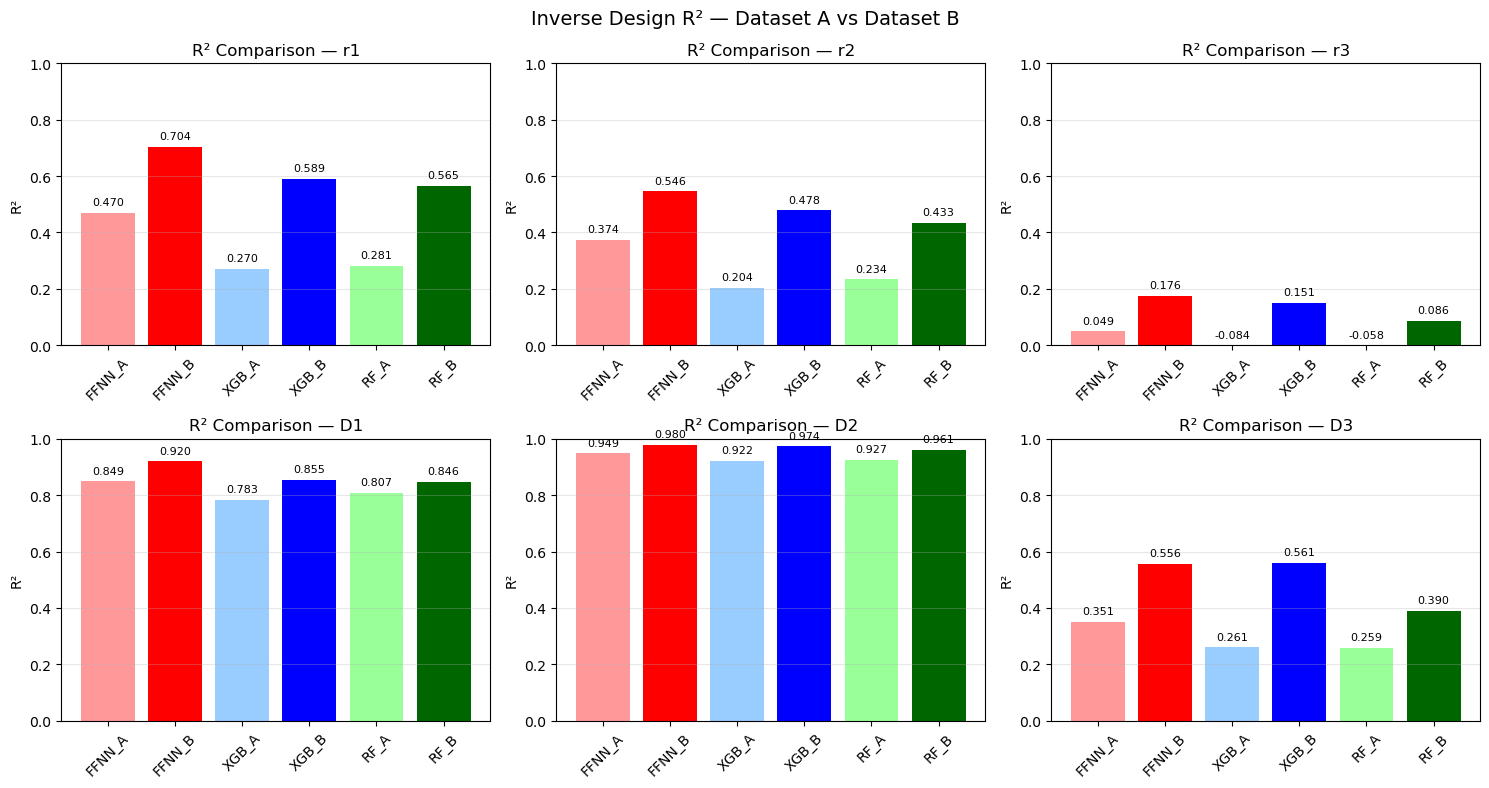

Plot saved!


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

models = ['FFNN_A', 'FFNN_B', 'XGB_A', 'XGB_B', 'RF_A', 'RF_B']
colors = ['#FF9999', '#FF0000', '#99CCFF', '#0000FF', '#99FF99', '#006600']

for idx, t in enumerate(targets):
    r2_vals = []
    for model_name in models:
        y_true, y_pred = results[model_name]
        r2 = r2_score(y_true[:, idx], y_pred[:, idx])
        r2_vals.append(r2)

    bars = axes[idx].bar(models, r2_vals, color=colors)
    axes[idx].set_title(f'R² Comparison — {t}', fontsize=12)
    axes[idx].set_ylabel('R²')
    axes[idx].set_ylim(0, 1)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar, val in zip(bars, r2_vals):
        axes[idx].text(bar.get_x() + bar.get_width()/2, 
                      max(val + 0.02, 0.02), 
                      f'{val:.3f}', 
                      ha='center', va='bottom', fontsize=8)

plt.suptitle('Inverse Design R² — Dataset A vs Dataset B', fontsize=14)
plt.tight_layout()
plt.savefig('r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

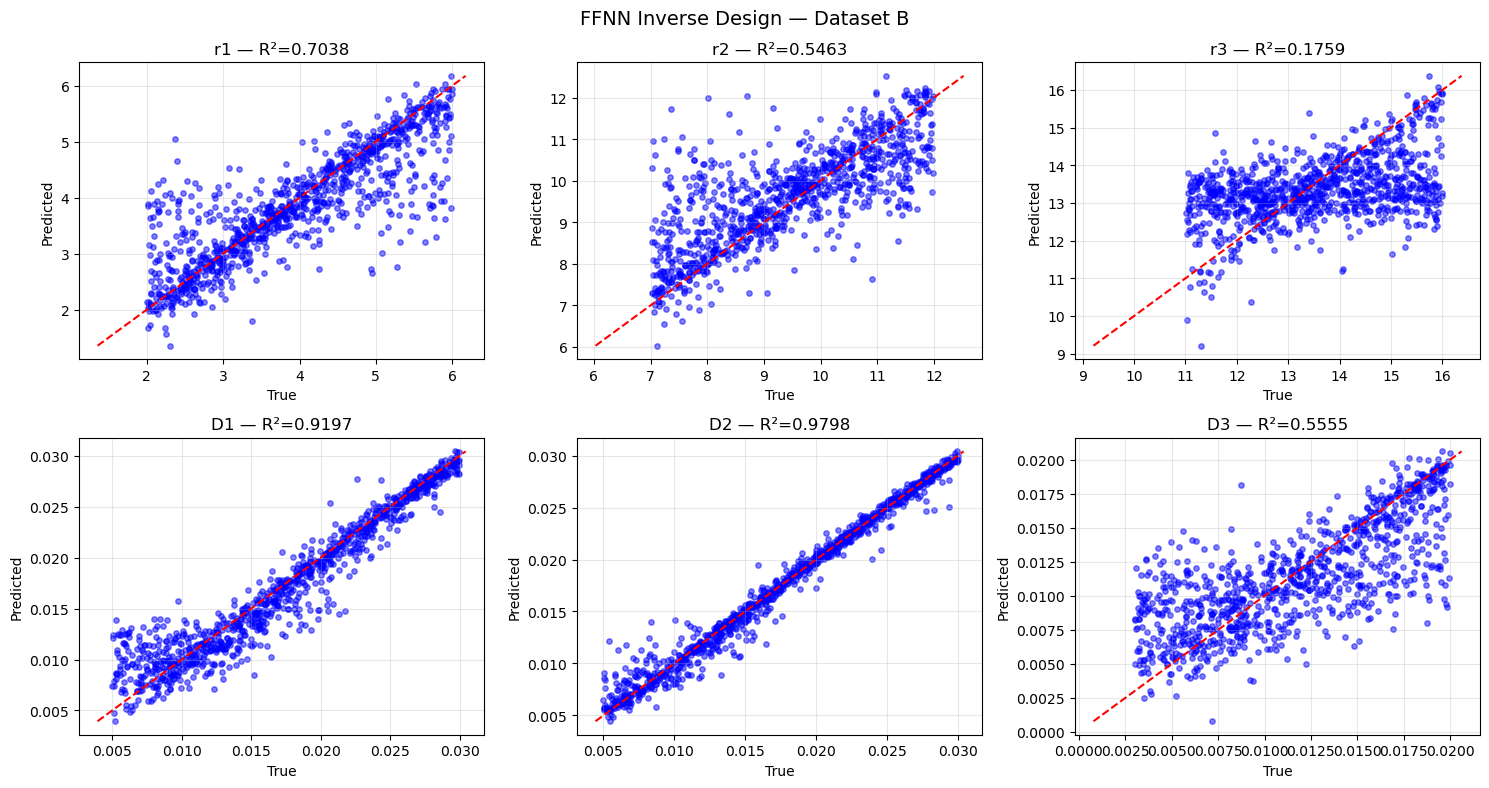

In [5]:
y_true, y_pred = results['FFNN_B']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, t in enumerate(targets):
    axes[idx].scatter(y_true[:, idx], y_pred[:, idx], 
                     alpha=0.5, s=15, color='blue', label='Dataset B')
    mn = min(y_true[:, idx].min(), y_pred[:, idx].min())
    mx = max(y_true[:, idx].max(), y_pred[:, idx].max())
    axes[idx].plot([mn, mx], [mn, mx], 'r--')
    r2 = r2_score(y_true[:, idx], y_pred[:, idx])
    axes[idx].set_title(f'{t} — R²={r2:.4f}')
    axes[idx].set_xlabel('True')
    axes[idx].set_ylabel('Predicted')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('FFNN Inverse Design — Dataset B', fontsize=14)
plt.tight_layout()
plt.savefig('scatter_FFNN_B.png', dpi=150, bbox_inches='tight')
plt.show()